# ECB Speeches → Minimal, Robust Supervised Pipeline (Keeps Metadata)

This notebook:
- Loads **speeches** (keeps all extra columns), auto-detects the **text** column, and concatenates `title + ". " + text` when available.
- Loads **daily MRO** (policy rate) and detects **effective change events** via differences.
- Labels each speech by the **next** effective change within **45 calendar days**: `+1` (hike), `-1` (cut), else `0`.
- Trains a **3-class TF-IDF + Logistic (elastic-net)** model.
- Evaluates with a **time-based split** (macro-F1 + normalized confusion matrix).

> Assumes:
> - Speeches CSV has at least a `date` column and one text-like column (e.g., `text`, `content`, `body`, ...).
> - MRO CSV has `date` and `mro_rate` columns.


In [ ]:
# =====================
# 0) Imports & Paths
# =====================
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Choose your data dir (adjust if needed)
ABS_DATA = Path(r"C:\Users\Garance Latieule\analyzing ECB\Analyzing-ECB\dataset")
REL_DATA = Path("./data")
DATA_DIR = ABS_DATA if ABS_DATA.exists() else REL_DATA

SPEECHES_CSV = DATA_DIR / "ecb_speeches_clean_minimal.csv"   # expects: date + one text-like column
MRO_CSV      = DATA_DIR / "ECB_portal_rates.csv"  # expects: date,mro_rate

print("[PATHS]")
print("DATA_DIR     :", DATA_DIR)
print("Speeches CSV :", SPEECHES_CSV, "| exists:", SPEECHES_CSV.exists())
print("MRO CSV      :", MRO_CSV,      "| exists:", MRO_CSV.exists())

[PATHS]
DATA_DIR     : C:\Users\Garance Latieule\analyzing ECB\Analyzing-ECB\dataset
Speeches CSV : C:\Users\Garance Latieule\analyzing ECB\Analyzing-ECB\dataset\ecb_speeches_clean_minimal.csv | exists: True
MRO CSV      : C:\Users\Garance Latieule\analyzing ECB\Analyzing-ECB\dataset\ecb_policy_rates_daily_fake.csv | exists: True


In [14]:
# =========================
# 1) Robust loaders (keep extra columns) + utilities
# =========================
TEXT_COL = None  # set to exact column name if you know it (e.g., "text"), else leave None

TEXT_CANDIDATES = [
    "text", "content", "body", "speech_text", "speech", "article", "clean_text"
]

META_COLS_HINT = ["title", "speaker", "url", "category", "doc_type"]

def _normalize_index(df: pd.DataFrame, date_col="date") -> pd.DataFrame:
    idx = pd.to_datetime(df[date_col], errors="coerce").dt.tz_localize(None).dt.normalize()
    out = df.copy()
    out.index = idx
    out = out[~out.index.isna()].sort_index()
    out = out[~out.index.duplicated(keep="first")]  # keep first if duplicate dates
    return out

def _pick_text_column(df: pd.DataFrame, explicit: str | None = None) -> str:
    if explicit and explicit in df.columns:
        return explicit
    for c in TEXT_CANDIDATES:
        if c in df.columns:
            non_empty = df[c].astype(str).str.strip().ne("").sum()
            if non_empty > 0:
                return c
    # fallback: last column
    return df.columns[-1]

def load_speeches_keep_meta(path: Path, text_col: str | None = None) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Speeches CSV not found: {path}")
    # Robust read: automatic delimiter sniffing (safe; no fragile escapechar)
    df = pd.read_csv(path, sep=None, engine="python", on_bad_lines="skip")
    if "date" not in df.columns:
        raise AssertionError("Speeches CSV must contain a 'date' column.")
    txt_col = _pick_text_column(df, text_col)
    df["__text_raw__"] = df[txt_col].astype(str)

    # Build unified 'text' while preserving meta columns
    if "title" in df.columns:
        title = df["title"].astype(str).str.strip()
        raw   = df["__text_raw__"]
        df["text"] = np.where(title.eq(""), raw, title + ". " + raw)
    else:
        df["text"] = df["__text_raw__"]

    df = _normalize_index(df, "date")
    meta_cols = [c for c in META_COLS_HINT if c in df.columns]
    cols_out = meta_cols + ["text"]
    if txt_col != "text" and txt_col in df.columns:
        cols_out = meta_cols + ["text", txt_col]  # keep original raw column for reference
    out = df[cols_out].copy()

    print(f"[OK] speeches: shape={out.shape} | span={out.index.min().date()}→{out.index.max().date()} | "
          f"text_col='{txt_col}' | metas={meta_cols}")
    n_empty = (out["text"].astype(str).str.strip() == "").sum()
    if n_empty:
        print(f"[WARN] empty 'text' rows: {n_empty}")
    return out

def load_mro_daily(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"MRO CSV not found: {path}")
    df = pd.read_csv(path, sep=None, engine="python", on_bad_lines="skip")
    if "date" not in df.columns or "mro_rate" not in df.columns:
        raise AssertionError("MRO CSV must have columns: 'date' and 'mro_rate'.")
    df["mro_rate"] = pd.to_numeric(df["mro_rate"], errors="coerce")
    df = df.dropna(subset=["mro_rate"])
    out = _normalize_index(df, "date")[["mro_rate"]]
    print(f"[OK] MRO daily: shape={out.shape} | uniq rates={out['mro_rate'].nunique()} | "
          f"span={out.index.min().date()}→{out.index.max().date()}")
    return out

[OK] speeches: shape=(2249, 2) | span=1997-02-07→2025-09-30 | text_col='text' | metas=['title']
[OK] MRO daily: shape=(2827, 1) | uniq rates=6 | span=2015-01-01→2025-10-31

[QA] SPEECHES — shape, span, meta presence
shape: (2249, 2)
span : 1997-02-07 → 2025-09-30
cols : ['title', 'text']
empty text rows: 0

[text length stats] min/median/mean/max: 3 2683 2959.466429524233 19638
short texts (<=25 words): 94


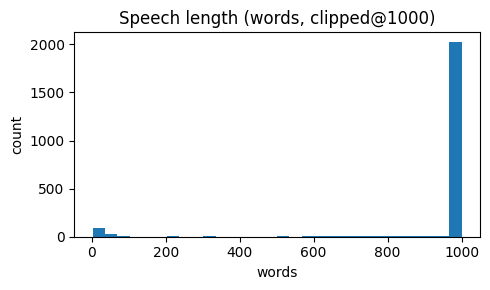


[QA] MRO — shape, span, nunique, head/tail
shape: (2827, 1) | span: 2015-01-01 → 2025-10-31
nunique rates: 6
head:
             mro_rate
date                
2015-01-01      0.75
2015-01-02      0.75
2015-01-05      0.75
tail:
             mro_rate
date                
2025-10-29       2.0
2025-10-30       2.0
2025-10-31       2.0

[QA] EVENTS — total, hikes, cuts
events total: 11 | hikes: 8 | cuts: 3


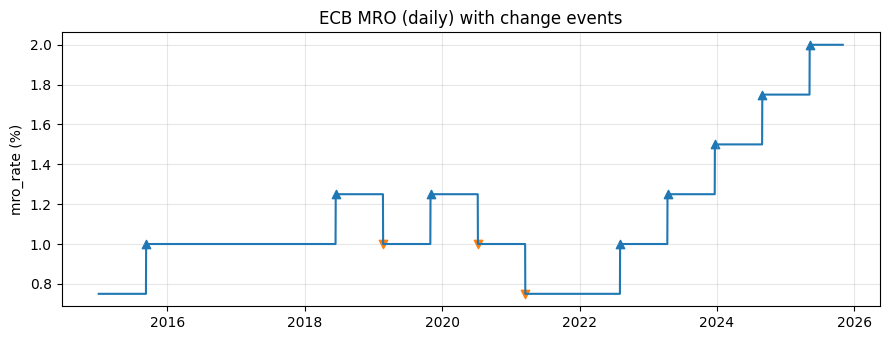


[QA] LABELS (3-class, next-change ≤45D): {0: 2135, 1: 80, -1: 34}


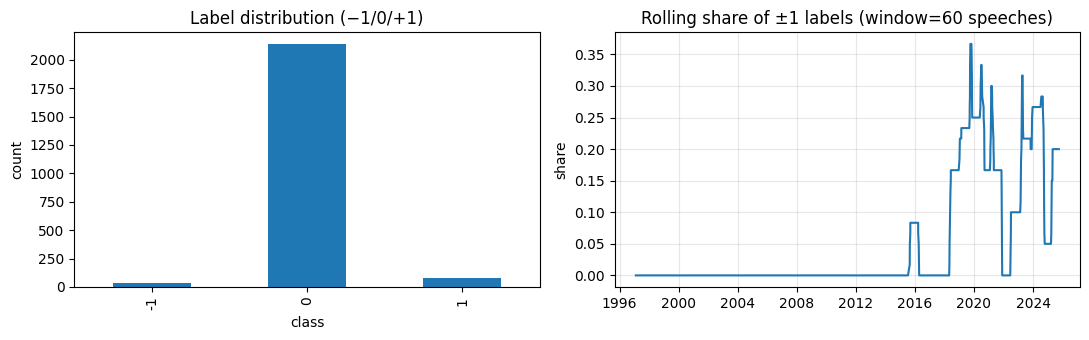

In [19]:
# =========================
# QA AFTER LOAD: sanity checks + quick plots + samples
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 0) Charger (ou recharger) les données brutes
speeches_all = load_speeches_keep_meta(SPEECHES_CSV, text_col=globals().get("TEXT_COL", None))
mro_daily    = load_mro_daily(MRO_CSV)

# 1) Quick overview (speeches)
print("\n[QA] SPEECHES — shape, span, meta presence")
print("shape:", speeches_all.shape)
print("span :", speeches_all.index.min().date(), "→", speeches_all.index.max().date())
print("cols :", list(speeches_all.columns))

n_empty = (speeches_all["text"].astype(str).str.strip() == "").sum()
print("empty text rows:", int(n_empty))
if n_empty:
    print("[WARN] Some empty 'text' rows; consider filtering them out.")

# Quelques stats texte
lens = speeches_all["text"].astype(str).str.split().map(len)
print("\n[text length stats] min/median/mean/max:",
      int(lens.min()), int(lens.median()), float(lens.mean()), int(lens.max()))
print("short texts (<=25 words):", int((lens<=25).sum()))

# Optionnel: histogramme des longueurs (rapide aperçu)
fig, ax = plt.subplots(figsize=(5,3))
ax.hist(lens.clip(0,1000), bins=30)  # clip pour lisibilité
ax.set_title("Speech length (words, clipped@1000)")
ax.set_xlabel("words"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

# 2) Quick overview (MRO)
print("\n[QA] MRO — shape, span, nunique, head/tail")
print("shape:", mro_daily.shape, "| span:", mro_daily.index.min().date(), "→", mro_daily.index.max().date())
print("nunique rates:", mro_daily["mro_rate"].nunique())
print("head:\n", mro_daily.head(3))
print("tail:\n", mro_daily.tail(3))

# 3) Événements & sanity
def compute_change_events(mro_df: pd.DataFrame) -> pd.DataFrame:
    s = mro_df["mro_rate"].astype(float).sort_index()
    delta = s.diff()
    ev_idx = delta[delta.fillna(0) != 0].index
    return pd.DataFrame({"change": np.sign(delta.loc[ev_idx]).astype(int).values}, index=ev_idx)

events = compute_change_events(mro_daily)
print("\n[QA] EVENTS — total, hikes, cuts")
print("events total:", len(events),
      "| hikes:", int((events["change"]==1).sum()),
      "| cuts:",  int((events["change"]==-1).sum()))

# Visual rapide MRO + events
fig, ax = plt.subplots(figsize=(9,3.5))
ax.plot(mro_daily.index, mro_daily["mro_rate"].values)
if len(events):
    ev_up = events.index[events["change"].eq(1)]
    ev_dw = events.index[events["change"].eq(-1)]
    ax.scatter(ev_up, mro_daily.reindex(ev_up)["mro_rate"], marker="^")
    ax.scatter(ev_dw, mro_daily.reindex(ev_dw)["mro_rate"], marker="v")
ax.set_title("ECB MRO (daily) with change events")
ax.set_ylabel("mro_rate (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 4) Labellisation next-change (3 classes) et distribution
def label_by_next_change_keep_meta(speeches_df: pd.DataFrame,
                                   events: pd.DataFrame,
                                   horizon_days: int = 45) -> pd.DataFrame:
    if "text" not in speeches_df.columns:
        raise AssertionError("'text' column missing after load.")
    left  = speeches_df.assign(_s=speeches_df.index).reset_index(drop=True)
    right = events.assign(_e=events.index).reset_index(drop=True)[["_e","change"]]
    merged = pd.merge_asof(
        left.sort_values("_s"), right.sort_values("_e"),
        left_on="_s", right_on="_e",
        direction="forward", tolerance=pd.Timedelta(f"{horizon_days}D")
    )
    out = speeches_df.copy()
    out["change_3cls"] = 0
    hits = merged["change"].notna()
    if hits.any():
        out.loc[merged.loc[hits, "_s"].values, "change_3cls"] = merged.loc[hits, "change"].astype(int).values
    return out

df_3 = label_by_next_change_keep_meta(speeches_all, events, horizon_days=45)

vc = df_3["change_3cls"].value_counts().to_dict()
print("\n[QA] LABELS (3-class, next-change ≤45D):", vc)

fig, ax = plt.subplots(1, 2, figsize=(11,3.5))
df_3["change_3cls"].value_counts().reindex([-1,0,1]).fillna(0).plot(kind="bar", ax=ax[0])
ax[0].set_title("Label distribution (−1/0/+1)")
ax[0].set_xlabel("class"); ax[0].set_ylabel("count")

roll = (df_3["change_3cls"]!=0).astype(int).rolling(60, min_periods=1).mean()
ax[1].plot(roll.index, roll.values); ax[1].grid(True, alpha=0.3)
ax[1].set_title("Rolling share of ±1 labels (window=60 speeches)")
ax[1].set_ylabel("share")
plt.tight_layout(); plt.show()

# 5) Coverage par meta (si présent) — utile pour savoir qui/quoi porte les labels
for col in ["speaker", "category", "doc_type"]:
    if col in df_3.columns:
        grp = df_3.groupby(col)["change_3cls"].value_counts().unstack(fill_value=0)
        print(f"\n[QA] Label counts by {col}:\n", grp.head(10))



In [21]:
# =========================
# 2) Events & labeling (keep metadata)
# =========================
def compute_change_events(mro_daily: pd.DataFrame) -> pd.DataFrame:
    s = mro_daily["mro_rate"].astype(float).sort_index()
    delta = s.diff()
    ev_idx = delta[delta.fillna(0) != 0].index
    events = pd.DataFrame({"change": np.sign(delta.loc[ev_idx]).astype(int).values}, index=ev_idx)
    print(f"[EVENTS] total={len(events)} | hikes={(events['change']==1).sum()} | cuts={(events['change']==-1).sum()}")
    return events

def label_by_next_change_keep_meta(speeches_df: pd.DataFrame,
                                   events: pd.DataFrame,
                                   horizon_days: int = 45) -> pd.DataFrame:
    if "text" not in speeches_df.columns:
        raise AssertionError("'text' column missing after load.")
    left  = speeches_df.assign(_s=speeches_df.index).reset_index(drop=True)
    right = events.assign(_e=events.index).reset_index(drop=True)[["_e","change"]]
    merged = pd.merge_asof(
        left.sort_values("_s"), right.sort_values("_e"),
        left_on="_s", right_on="_e",
        direction="forward", tolerance=pd.Timedelta(f"{horizon_days}D")
    )
    out = speeches_df.copy()
    out["change_3cls"] = 0
    hits = merged["change"].notna()
    if hits.any():
        out.loc[merged.loc[hits, "_s"].values, "change_3cls"] = merged.loc[hits, "change"].astype(int).values
    counts = out["change_3cls"].value_counts().to_dict()
    print(f"[LABELS] next-change ≤{horizon_days}D: {counts}")
    return out

In [16]:
# =========================
# 3) Train & evaluate (time split)
# =========================
def train_eval_time_split(df_3: pd.DataFrame, train_frac: float = 0.8):
    if df_3 is None or len(df_3) == 0 or "change_3cls" not in df_3.columns:
        print("[TRAIN] Invalid 3-class dataframe.")
        return None
    df_3 = df_3.sort_index()
    cut = int(len(df_3) * train_frac)
    X_train, y_train = df_3.iloc[:cut]["text"], df_3.iloc[:cut]["change_3cls"]
    X_test,  y_test  = df_3.iloc[cut:]["text"],  df_3.iloc[cut:]["change_3cls"]

    if y_train.nunique() < 2 or y_test.nunique() < 2:
        print("[TRAIN] Not enough classes in split; try a larger horizon_days.")
        return None

    pipe = Pipeline(steps=[
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2), max_features=12000,
            lowercase=True, strip_accents="unicode",
            stop_words="english",
            token_pattern=r"\b[a-zA-Z]{3,}\b"
        )),
        ("clf", LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5,
            class_weight="balanced", max_iter=6000, C=1.0,
            n_jobs=-1, random_state=0
        )),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"[SPLIT] train={len(X_train)} | test={len(X_test)}")
    print("\n[REPORT] macro-F1 is key due to imbalance")
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1], normalize="true")
    cm_df = pd.DataFrame(cm,
                         index=["true -1", "true 0", "true +1"],
                         columns=["pred -1", "pred 0", "pred +1"])
    print("\n[CONFUSION] normalized (rows=true)")
    print(cm_df.round(3).to_string())
    return pipe

In [17]:
# =========================
# 4) Run
# =========================
#speeches_all = load_speeches_keep_meta(SPEECHES_CSV, text_col=TEXT_COL)
#mro_daily    = load_mro_daily(MRO_CSV)
#events       = compute_change_events(mro_daily)

#df_3 = label_by_next_change_keep_meta(speeches_all, events, horizon_days=45)
#model = train_eval_time_split(df_3, train_frac=0.8)